In [1]:
# Imports
import numpy as np
import pandas as pd
import xgboost as xgb
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
feature_matrix = np.load("../data/feature_matrix.npy")
labels_list = np.load("../data/labels.npy")
feature_names = json.load(open("../data/feature_names.json"))

with open("../data/clean_msmarco.json") as f:
    data = json.load(f)

print(f"Feature matrix: {feature_matrix.shape}")
print(f"Labels: {labels_list.shape}")
print(f"Features: {len(feature_names)}")

Feature matrix: (39962, 23)
Labels: (39962,)
Features: 23


In [3]:
# Build Group Array
groups = np.array([len(item['passages']) for item in data])

print(f"Total queries: {len(groups)}")
print(f"Total passages: {groups.sum()}")
print(f"Avg passages per query: {groups.mean():.1f}")

Total queries: 4851
Total passages: 39962
Avg passages per query: 8.2


In [4]:
# Group-Aware Train/Test Split
cumsum = np.cumsum(np.concatenate([[0], groups]))
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(np.arange(len(data)), groups=np.arange(len(data))))

def get_idx(q_idx): return np.concatenate([np.arange(cumsum[i], cumsum[i+1]) for i in q_idx])

train_p, test_p = get_idx(train_idx), get_idx(test_idx)
X_train, y_train = feature_matrix[train_p], labels_list[train_p]
X_test, y_test = feature_matrix[test_p], labels_list[test_p]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train: {len(train_idx)} queries | {len(train_p)} passages")
print(f"Test: {len(test_idx)} queries | {len(test_p)} passages")

Train: 3880 queries | 31938 passages
Test: 971 queries | 8024 passages


In [5]:
# XGBoost DMatrix Preparation
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

dtrain.set_group(groups_train)
dtest.set_group(groups_test)

print(f"DMatrix ready!")
print(f"Train: {dtrain.num_row()} rows | Test: {dtest.num_row()} rows")

DMatrix ready!
Train: 31938 rows | Test: 8024 rows


In [6]:
# Hyperparameter Tuning
params_list = [
    {'max_depth': 4, 'eta': 0.1, 'min_child_weight': 5},
    {'max_depth': 6, 'eta': 0.05, 'min_child_weight': 3},
    {'max_depth': 8, 'eta': 0.01, 'min_child_weight': 1},
]

best_score, best_params = 0, None
for params in params_list:
    params.update({'objective': 'rank:ndcg', 'eval_metric': 'ndcg@10', 'tree_method': 'hist'})
    cv = xgb.cv(params, dtrain, num_boost_round=100, nfold=3, metrics='ndcg@10', seed=42, verbose_eval=False)
    score = cv['test-ndcg@10-mean'].max()
    print(f"Params: {params['max_depth']},{params['eta']},{params['min_child_weight']} | NDCG@10: {score:.4f}")
    if score > best_score:
        best_score, best_params = score, params

print(f"\nBest params: {best_params} | Score: {best_score:.4f}")

Params: 4,0.1,5 | NDCG@10: 0.5999
Params: 6,0.05,3 | NDCG@10: 0.5971
Params: 8,0.01,1 | NDCG@10: 0.5871

Best params: {'max_depth': 4, 'eta': 0.1, 'min_child_weight': 5, 'objective': 'rank:ndcg', 'eval_metric': 'ndcg@10', 'tree_method': 'hist'} | Score: 0.5999


In [8]:
# Train Final LambdaMART Model with Early Stopping
evals_result = {}
model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    evals_result=evals_result,
    early_stopping_rounds=20,
    verbose_eval=50
)

print(f"Best round: {model.best_iteration}")
print(f"Best test NDCG@10: {model.best_score:.4f}")

[0]	train-ndcg@10:0.57738	test-ndcg@10:0.55344
[36]	train-ndcg@10:0.67946	test-ndcg@10:0.59559
Best round: 16
Best test NDCG@10: 0.5974


In [9]:
# Predict and Re-rank
y_pred = model.predict(dtest)

# Re-rank within each query group
cumsum = np.cumsum(np.concatenate([[0], groups_test]))
ranked_results = []
for i in range(len(groups_test)):
    start, end = cumsum[i], cumsum[i+1]
    scores = y_pred[start:end]
    labels = y_test[start:end]
    order = np.argsort(scores)[::-1]
    ranked_results.append({'scores': scores[order].tolist(), 'labels': labels[order].tolist()})

print(f"Re-ranked {len(ranked_results)} queries!")
print(f"Sample scores: {ranked_results[0]['scores'][:5]}")

Re-ranked 971 queries!
Sample scores: [0.279577374458313, 0.1177767962217331, -0.2389823943376541, -0.35754677653312683, -0.3609837591648102]


In [10]:
# Compute All Metrics
def safe_metrics(labels, scores):
    order = np.argsort(scores)[::-1]
    labels = np.array(labels)
    mrr = next((1/(r+1) for r, i in enumerate(order) if labels[i]==1), 0)
    p_k = sum(labels[order[:10]])/min(10, len(labels))
    dcg = sum(labels[order[r]]/np.log2(r+2) for r in range(min(10, len(order))))
    idcg = sum(1/np.log2(r+2) for r in range(min(int(sum(labels)), 10)))
    return mrr, p_k, dcg/idcg if idcg > 0 else 0

metrics = [safe_metrics(r['labels'], r['scores']) for r in ranked_results]
mrr, p_k, ndcg = np.mean(metrics, axis=0)

print(f"LambdaMART NDCG@10:     {ndcg:.4f}")
print(f"LambdaMART MRR:         {mrr:.4f}")
print(f"LambdaMART Precision@10:{p_k:.4f}")

LambdaMART NDCG@10:     0.5956
LambdaMART MRR:         0.4703
LambdaMART Precision@10:0.1394


In [11]:
# Compare BM25 vs LambdaMART
baseline = json.load(open("../data/baseline_score.json"))

comparison = pd.DataFrame({
    'Metric': ['NDCG@10', 'MRR', 'Precision@10'],
    'BM25': [baseline['ndcg@10'], baseline['mrr'], baseline['precision@10']],
    'LambdaMART': [round(ndcg,4), round(mrr,4), round(p_k,4)]
})
comparison['Improvement'] = ((comparison['LambdaMART'] - comparison['BM25']) / comparison['BM25'] * 100).round(2).astype(str) + '%'

print(comparison.to_string(index=False))

      Metric   BM25  LambdaMART Improvement
     NDCG@10 0.5069      0.5956       17.5%
         MRR 0.3573      0.4703      31.63%
Precision@10 0.1406      0.1394      -0.85%


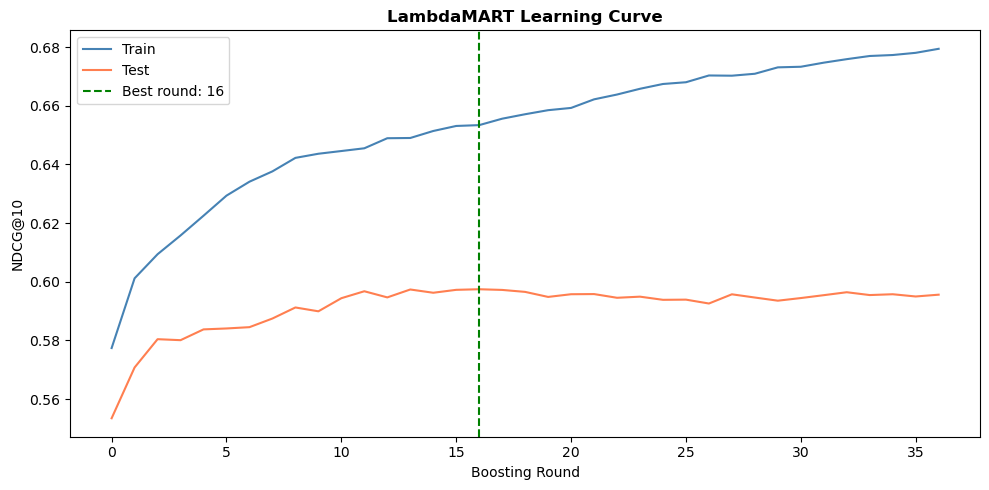

In [12]:
# Learning Curve Plot
plt.figure(figsize=(10, 5))
plt.plot(evals_result['train']['ndcg@10'], label='Train', color='steelblue')
plt.plot(evals_result['test']['ndcg@10'], label='Test', color='coral')
plt.axvline(model.best_iteration, color='green', linestyle='--', label=f'Best round: {model.best_iteration}')
plt.title("LambdaMART Learning Curve", fontweight='bold')
plt.xlabel("Boosting Round")
plt.ylabel("NDCG@10")
plt.legend()
plt.tight_layout()
plt.savefig("../data/learning_curve.png", dpi=150)
plt.show()

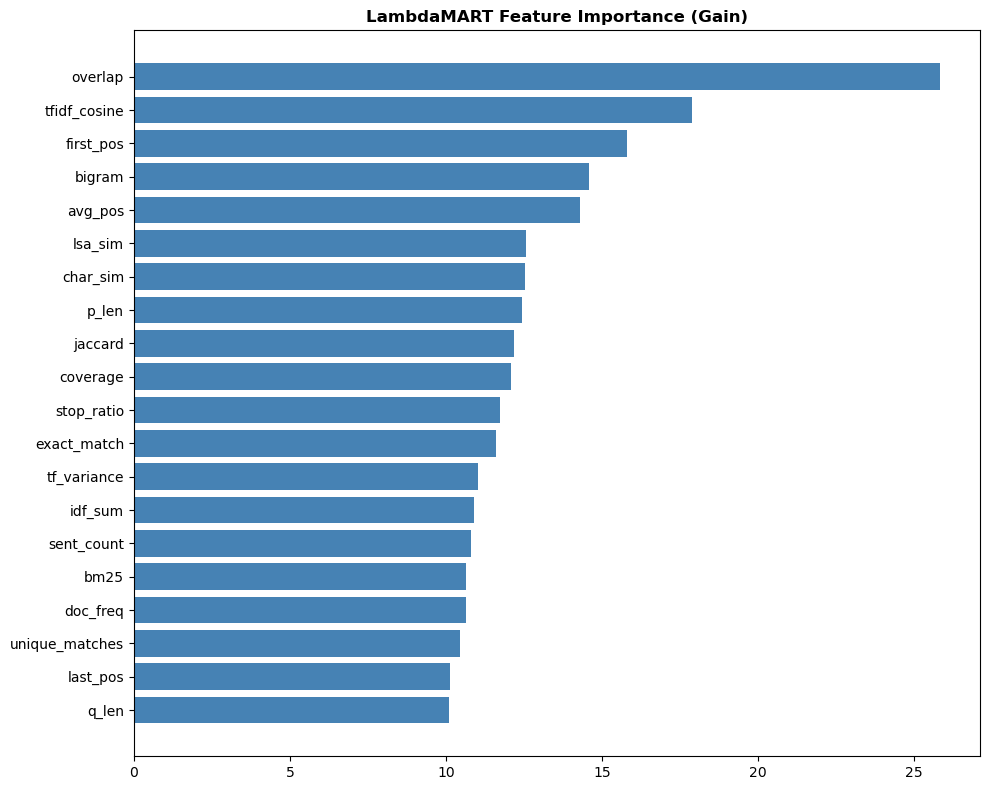

In [13]:
# LambdaMART Feature Importance
importance = model.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(importance.keys()), 
                       'importance': list(importance.values())}).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.title("LambdaMART Feature Importance (Gain)", fontweight='bold')
plt.tight_layout()
plt.savefig("../data/lambdamart_importance.png", dpi=150)
plt.show()

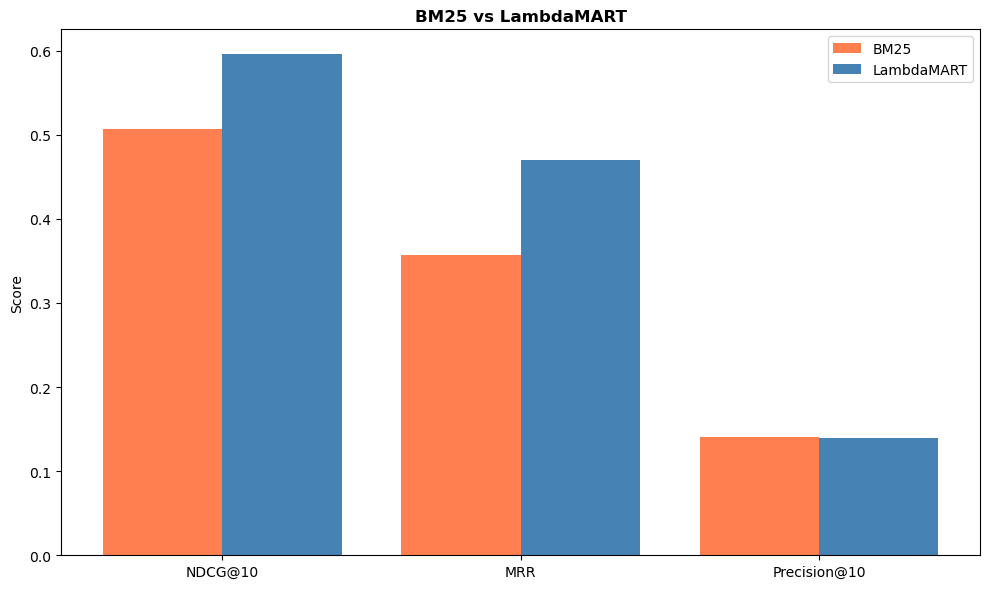

In [14]:
# BM25 vs LambdaMART Comparison Chart
metrics_names = ['NDCG@10', 'MRR', 'Precision@10']
bm25_scores = [baseline['ndcg@10'], baseline['mrr'], baseline['precision@10']]
lm_scores = [round(ndcg,4), round(mrr,4), round(p_k,4)]

x = np.arange(len(metrics_names))
plt.figure(figsize=(10, 6))
plt.bar(x-0.2, bm25_scores, 0.4, label='BM25', color='coral')
plt.bar(x+0.2, lm_scores, 0.4, label='LambdaMART', color='steelblue')
plt.xticks(x, metrics_names)
plt.title("BM25 vs LambdaMART", fontweight='bold')
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("../data/model_comparison.png", dpi=150)
plt.show()

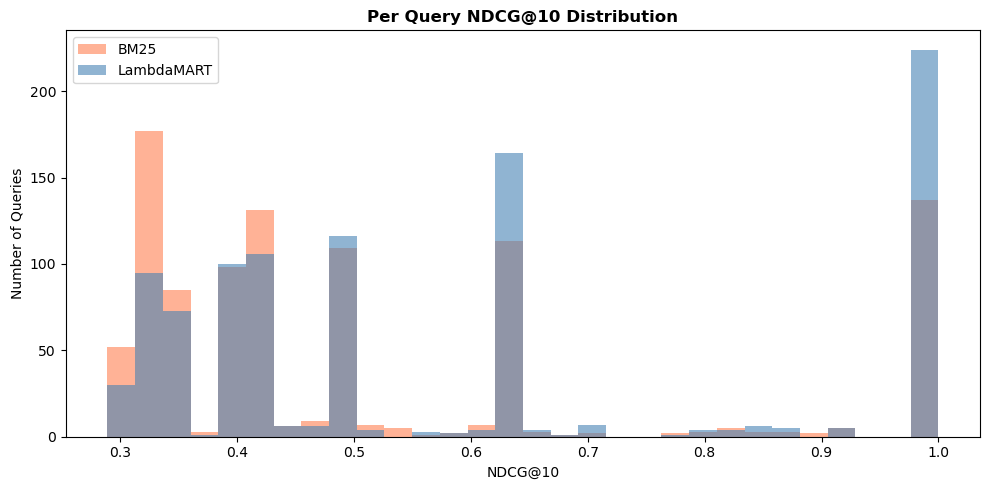

In [15]:
# Per Query NDCG Distribution
bm25_ndcg = [safe_metrics(item['labels'], res['scores'])[2] 
             for item, res in zip([data[i] for i in test_idx], ranked_results)]

plt.figure(figsize=(10, 5))
plt.hist(bm25_ndcg, bins=30, alpha=0.6, color='coral', label='BM25')
plt.hist([m[2] for m in metrics], bins=30, alpha=0.6, color='steelblue', label='LambdaMART')
plt.title("Per Query NDCG@10 Distribution", fontweight='bold')
plt.xlabel("NDCG@10")
plt.ylabel("Number of Queries")
plt.legend()
plt.tight_layout()
plt.savefig("../data/ndcg_distribution.png", dpi=150)
plt.show()

In [16]:
# Error Analysis
test_data = [data[i] for i in test_idx]
query_metrics = [(item['query'], m[2], b) for item, m, b in zip(test_data, metrics, bm25_ndcg)]

worst = sorted(query_metrics, key=lambda x: x[1])[:5]
best = sorted(query_metrics, key=lambda x: x[1]-x[2], reverse=True)[:5]

print("Top 5 queries LambdaMART FAILED:")
for q, lm, bm in worst:
    print(f"  NDCG: {lm:.3f} | Query: {q}")

print("\nTop 5 queries LambdaMART IMPROVED MOST:")
for q, lm, bm in best:
    print(f"  Improvement: {lm-bm:.3f} | Query: {q}")

Top 5 queries LambdaMART FAILED:
  NDCG: 0.289 | Query: where are precambrian rocks found
  NDCG: 0.289 | Query: which aloe is good for skin
  NDCG: 0.289 | Query: why is nuclear energy bad
  NDCG: 0.289 | Query: the axons of the retinal culminated in the optic nerve which forms a spot on the retina
  NDCG: 0.289 | Query: is rnav considered instrument approach

Top 5 queries LambdaMART IMPROVED MOST:
  Improvement: 0.711 | Query: according to stalin what effect did disobeying the pact have on germany
  Improvement: 0.711 | Query: where is lula georgia
  Improvement: 0.711 | Query: how to calculate your salary worth
  Improvement: 0.711 | Query: what is nkandla
  Improvement: 0.699 | Query: highest interest rates in usa


In [17]:
# Save Model and Results
model.save_model("../models/lambdamart_model.json")

results = {
    "model": "LambdaMART",
    "best_round": model.best_iteration,
    "ndcg@10": round(ndcg, 4),
    "mrr": round(mrr, 4),
    "precision@10": round(p_k, 4),
    "improvement_ndcg": f"{((ndcg-baseline['ndcg@10'])/baseline['ndcg@10']*100):.2f}%",
    "improvement_mrr": f"{((mrr-baseline['mrr'])/baseline['mrr']*100):.2f}%",
    "best_params": best_params
}

json.dump(results, open("../data/lambdamart_results.json", "w"))
print(json.dumps(results, indent=2))

{
  "model": "LambdaMART",
  "best_round": 16,
  "ndcg@10": 0.5956,
  "mrr": 0.4703,
  "precision@10": 0.1394,
  "improvement_ndcg": "17.50%",
  "improvement_mrr": "31.64%",
  "best_params": {
    "max_depth": 4,
    "eta": 0.1,
    "min_child_weight": 5,
    "objective": "rank:ndcg",
    "eval_metric": "ndcg@10",
    "tree_method": "hist"
  }
}
